1. COLETANDO DADOS DAS AÇÕES...
Baixando período pré-pandemia (2010–2019)...


[*********************100%***********************]  4 of 4 completed
[                       0%                       ]

Baixando período pós-pandemia (2023–2025)...


[*********************100%***********************]  4 of 4 completed



2. ENGENHARIA DE FEATURES TÉCNICAS

Features por ação: Close, Volume, MA7, MA21, RSI14, Retorno
Total: 6 features × 4 ações = 24 colunas
Dias úteis após limpeza: 3189

3. MATRIZ DE CORRELAÇÃO (RETORNOS)

                   Itaú  Bradesco  Banco do Brasil  Santander
Itaú             1.0000    0.7859           0.6794     0.6575
Bradesco         0.7859    1.0000           0.6195     0.6113
Banco do Brasil  0.6794    0.6195           1.0000     0.5411
Santander        0.6575    0.6113           0.5411     1.0000


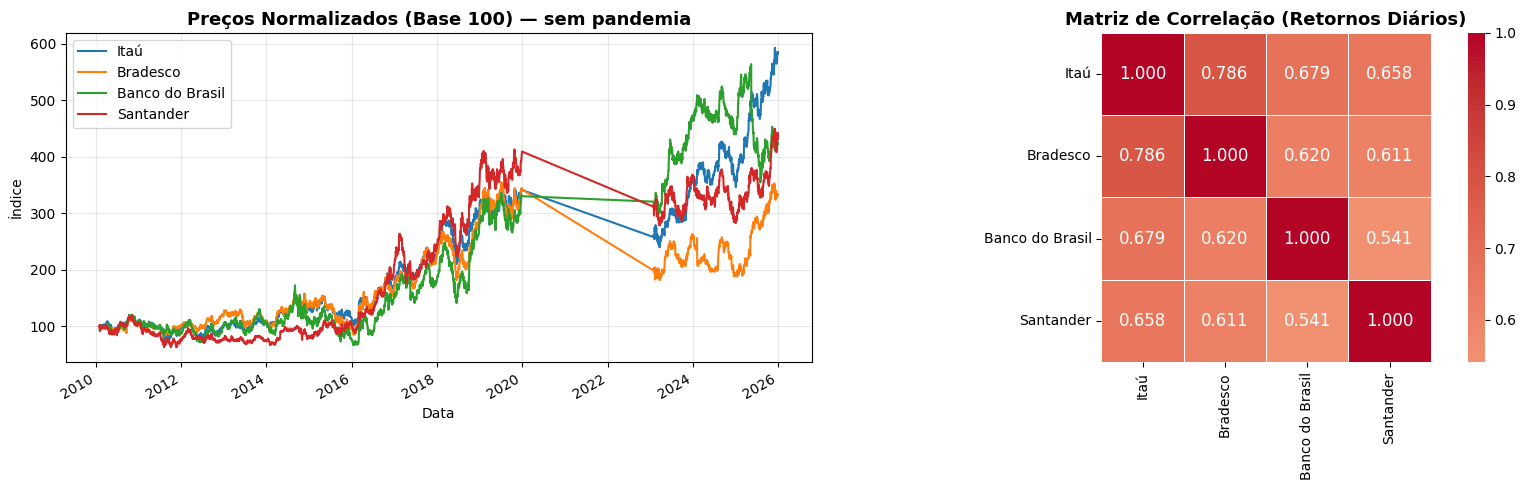

Gráfico salvo: 1_eda_correlacao.png

4. PRÉ-PROCESSAMENTO
Sequências: X=(3129, 60, 24), y=(3129, 4)
Treino: 2628 amostras  (até 2024-01-01)
Teste:  501 amostras   (a partir de 2024-01-01)

5. ARQUITETURA DO MODELO LSTM

LSTMModel(
  (lstm): LSTM(24, 128, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=128, out_features=4, bias=True)
)

Input size: 24 features | Parâmetros: 211,460

6. TREINAMENTO COM EARLY STOPPING
Época [  1/150] | Treino: 0.006598 | Teste: 0.039310 | LR: 0.001000 | ES: 0/15
Época [ 10/150] | Treino: 0.002234 | Teste: 0.020235 | LR: 0.001000 | ES: 0/15


In [ ]:
# =============================================================================
# Série Temporal com LSTM - PyTorch (v2 — Melhorias Alta Prioridade)
# Ações: ITUB4, BBDC4, BBAS3, SANB11
# Período: 2010-2019 + 2023-2025 (excluindo pandemia 2020-2022)
# Melhorias: seq_len=60 | features técnicas | early stopping
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import yfinance as yf
import warnings
warnings.filterwarnings("ignore")

torch.manual_seed(42)
np.random.seed(42)

# =============================================================================
# 1. COLETA DE DADOS
# =============================================================================

print("=" * 60)
print("1. COLETANDO DADOS DAS AÇÕES...")
print("=" * 60)

TICKERS = ["ITUB4.SA", "BBDC4.SA", "BBAS3.SA", "SANB11.SA"]
NOMES   = ["Itaú", "Bradesco", "Banco do Brasil", "Santander"]

print("Baixando período pré-pandemia (2010–2019)...")
df_pre = yf.download(TICKERS, start="2010-01-01", end="2019-12-31")

print("Baixando período pós-pandemia (2023–2025)...")
df_pos = yf.download(TICKERS, start="2023-01-01", end="2025-12-31")

# =============================================================================
# 2. ENGENHARIA DE FEATURES TÉCNICAS
# =============================================================================

print("\n" + "=" * 60)
print("2. ENGENHARIA DE FEATURES TÉCNICAS")
print("=" * 60)

def compute_rsi(series, period=14):
    """Calcula o RSI (Relative Strength Index)."""
    delta    = series.diff()
    gain     = delta.clip(lower=0)
    loss     = -delta.clip(upper=0)
    avg_gain = gain.rolling(period).mean()
    avg_loss = loss.rolling(period).mean()
    rs  = avg_gain / (avg_loss + 1e-9)
    return 100 - (100 / (1 + rs))

def build_features(df_ohlcv, nome):
    """
    Constrói features técnicas para uma ação.
    Features: Close, Volume, MA7, MA21, RSI14, Retorno
    """
    close  = df_ohlcv["Close"]
    volume = df_ohlcv["Volume"]

    features = pd.DataFrame(index=close.index)
    features[f"{nome}_Close"]   = close
    features[f"{nome}_Volume"]  = volume
    features[f"{nome}_MA7"]     = close.rolling(7).mean()
    features[f"{nome}_MA21"]    = close.rolling(21).mean()
    features[f"{nome}_RSI14"]   = compute_rsi(close, 14)
    features[f"{nome}_Retorno"] = close.pct_change() * 100
    return features

# Constrói features para cada ação e cada bloco temporal
all_features = []
for df_bloco in [df_pre, df_pos]:
    bloco_features = []
    for ticker, nome in zip(TICKERS, NOMES):
        df_ticker = pd.DataFrame({
            "Close":  df_bloco["Close"][ticker],
            "Volume": df_bloco["Volume"][ticker],
        })
        bloco_features.append(build_features(df_ticker, nome))
    all_features.append(pd.concat(bloco_features, axis=1))

df_features = pd.concat(all_features)
df_features.sort_index(inplace=True)
df_features.dropna(inplace=True)

close_cols = [f"{nome}_Close" for nome in NOMES]
n_features = df_features.shape[1]

print(f"\nFeatures por ação: Close, Volume, MA7, MA21, RSI14, Retorno")
print(f"Total: 6 features × 4 ações = {n_features} colunas")
print(f"Dias úteis após limpeza: {len(df_features)}")

# =============================================================================
# 3. ANÁLISE EXPLORATÓRIA — CORRELAÇÃO
# =============================================================================

print("\n" + "=" * 60)
print("3. MATRIZ DE CORRELAÇÃO (RETORNOS)")
print("=" * 60)

retornos = df_features[close_cols].pct_change().dropna()
retornos.columns = NOMES
corr = retornos.corr()
print(f"\n{corr.round(4)}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

closes = df_features[close_cols].copy()
closes.columns = NOMES
(closes / closes.iloc[0] * 100).plot(ax=axes[0], linewidth=1.5)
axes[0].set_title("Preços Normalizados (Base 100) — sem pandemia", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Data")
axes[0].set_ylabel("Índice")
axes[0].grid(alpha=0.3)

sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm",
            center=0, ax=axes[1], square=True,
            linewidths=0.5, annot_kws={"size": 12})
axes[1].set_title("Matriz de Correlação (Retornos Diários)", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("1_eda_correlacao.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico salvo: 1_eda_correlacao.png")

# =============================================================================
# 4. PRÉ-PROCESSAMENTO
# =============================================================================

print("\n" + "=" * 60)
print("4. PRÉ-PROCESSAMENTO")
print("=" * 60)

SEQ_LEN    = 60          # ✅ Melhoria 1: janela ampliada 30 → 60 dias
BATCH_SIZE = 32
SPLIT_DATE = "2024-01-01"

scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(df_features.values)

scaler_close = MinMaxScaler(feature_range=(0, 1))
scaler_close.fit(df_features[close_cols].values)

def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len])  # (seq_len, n_features)
        y.append(data[i + seq_len, :4])  # 4 preços de fechamento
    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, SEQ_LEN)
datas = df_features.index[SEQ_LEN:]
split_idx = np.searchsorted(datas, pd.Timestamp(SPLIT_DATE))

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
datas_teste = datas[split_idx:]

print(f"Sequências: X={X.shape}, y={y.shape}")
print(f"Treino: {X_train.shape[0]} amostras  (até {SPLIT_DATE})")
print(f"Teste:  {X_test.shape[0]} amostras   (a partir de {SPLIT_DATE})")

X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train)
X_test_t  = torch.FloatTensor(X_test)
y_test_t  = torch.FloatTensor(y_test)

# =============================================================================
# 5. DATASET & DATALOADER
# =============================================================================

class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(StockDataset(X_train_t, y_train_t),
                          batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(StockDataset(X_test_t, y_test_t),
                          batch_size=BATCH_SIZE, shuffle=False)

# =============================================================================
# 6. MODELO LSTM
# =============================================================================

print("\n" + "=" * 60)
print("5. ARQUITETURA DO MODELO LSTM")
print("=" * 60)

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)  # ✅ Dropout antes da camada linear
        self.fc      = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        out, _ = self.lstm(x, (h0, c0))
        out = self.dropout(out[:, -1, :])
        out = self.fc(out)
        return out

INPUT_SIZE  = n_features  # 24 features (6 × 4 ações)
HIDDEN_SIZE = 128
NUM_LAYERS  = 2
OUTPUT_SIZE = 4
DROPOUT     = 0.2

model = LSTMModel(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUTPUT_SIZE, DROPOUT)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n{model}")
print(f"\nInput size: {INPUT_SIZE} features | Parâmetros: {total_params:,}")

# =============================================================================
# 7. TREINAMENTO COM EARLY STOPPING
# =============================================================================

print("\n" + "=" * 60)
print("6. TREINAMENTO COM EARLY STOPPING")
print("=" * 60)

EPOCHS   = 150
LR       = 0.001
PATIENCE = 15   # ✅ Melhoria 2: Early Stopping

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=10, factor=0.5
)

class EarlyStopping:
    def __init__(self, patience=15, min_delta=1e-6):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_loss  = None
        self.stop       = False
        self.best_state = None

    def __call__(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.counter    = 0
            self.best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

early_stopping = EarlyStopping(patience=PATIENCE)
train_losses, test_losses = [], []

for epoch in range(1, EPOCHS + 1):
    # Treino
    model.train()
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss   = criterion(y_pred, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()
    avg_train = epoch_loss / len(train_loader)

    # Validação
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            val_loss += criterion(model(X_batch), y_batch).item()
    avg_val = val_loss / len(test_loader)

    scheduler.step(avg_val)
    train_losses.append(avg_train)
    test_losses.append(avg_val)
    early_stopping(avg_val, model)

    if epoch % 10 == 0 or epoch == 1:
        lr_atual = optimizer.param_groups[0]['lr']
        print(f"Época [{epoch:3d}/{EPOCHS}] | "
              f"Treino: {avg_train:.6f} | "
              f"Teste: {avg_val:.6f} | "
              f"LR: {lr_atual:.6f} | "
              f"ES: {early_stopping.counter}/{PATIENCE}")

    if early_stopping.stop:
        print(f"\n⏹️  Early stopping na época {epoch}!")
        print(f"   Melhor loss: {early_stopping.best_loss:.6f}")
        model.load_state_dict(early_stopping.best_state)
        break

# =============================================================================
# 8. CURVA DE APRENDIZADO
# =============================================================================

plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Loss Treino", color="#2196F3", linewidth=2)
plt.plot(test_losses,  label="Loss Teste",  color="#F44336", linewidth=2)
best_ep = int(np.argmin(test_losses))
plt.axvline(best_ep, color="green", linestyle="--", label=f"Melhor época ({best_ep + 1})")
plt.xlabel("Época")
plt.ylabel("MSE Loss")
plt.title("Curva de Aprendizado — LSTM v2", fontsize=13, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("2_loss_curva.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico salvo: 2_loss_curva.png")

# =============================================================================
# 9. AVALIAÇÃO
# =============================================================================

print("\n" + "=" * 60)
print("7. AVALIAÇÃO NO CONJUNTO DE TESTE")
print("=" * 60)

model.eval()
with torch.no_grad():
    preds_scaled = model(X_test_t).numpy()
    real_scaled  = y_test_t.numpy()

preds_real = scaler_close.inverse_transform(preds_scaled)
real_real  = scaler_close.inverse_transform(real_scaled)

def directional_accuracy(real, pred):
    """Acurácia direcional: % de acerto na direção do movimento."""
    return np.mean(np.sign(np.diff(real)) == np.sign(np.diff(pred))) * 100

print(f"\n{'Ação':<18} {'RMSE':>8} {'MAE':>8} {'MAPE':>8} {'Direcional':>12}")
print("-" * 58)
for i, nome in enumerate(NOMES):
    rmse = np.sqrt(mean_squared_error(real_real[:, i], preds_real[:, i]))
    mae  = mean_absolute_error(real_real[:, i], preds_real[:, i])
    mape = np.mean(np.abs((real_real[:, i] - preds_real[:, i]) / real_real[:, i])) * 100
    dacc = directional_accuracy(real_real[:, i], preds_real[:, i])
    print(f"{nome:<18} {rmse:>8.2f} {mae:>8.2f} {mape:>7.2f}% {dacc:>11.1f}%")

# =============================================================================
# 10. GRÁFICOS DE PREVISÃO
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes  = axes.flatten()
cores = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0"]

for i, (nome, cor) in enumerate(zip(NOMES, cores)):
    axes[i].plot(datas_teste, real_real[:, i],  label="Real",     color=cor,   linewidth=1.5)
    axes[i].plot(datas_teste, preds_real[:, i], label="Previsto", color="red", linewidth=1.2,
                 linestyle="--", alpha=0.85)
    axes[i].set_title(f"{nome} ({TICKERS[i].replace('.SA', '')})", fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Data")
    axes[i].set_ylabel("Preço (R$)")
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.suptitle("LSTM v2 — Previsão vs. Real (Conjunto de Teste)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("3_previsoes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico salvo: 3_previsoes.png")

# =============================================================================
# 11. SALVAR MODELO
# =============================================================================

torch.save({
    "model_state_dict": model.state_dict(),
    "scaler":           scaler,
    "scaler_close":     scaler_close,
    "tickers":          TICKERS,
    "features":         list(df_features.columns),
    "hyperparams": {
        "input_size":  INPUT_SIZE,
        "hidden_size": HIDDEN_SIZE,
        "num_layers":  NUM_LAYERS,
        "output_size": OUTPUT_SIZE,
        "dropout":     DROPOUT,
        "seq_len":     SEQ_LEN,
    }
}, "lstm_acoes_bancarias_v2.pt")

print("\n" + "=" * 60)
print("✅ CONCLUÍDO! Arquivos gerados:")
print("  - lstm_acoes_bancarias_v2.pt")
print("  - 1_eda_correlacao.png")
print("  - 2_loss_curva.png")
print("  - 3_previsoes.png")
print("=" * 60)